In [1]:
import pandas as pd
import random
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle,Rectangle, Patch
import numpy as np

In [2]:
## Get the number of antibiotic resistances genes by types of abr using SPARQL queries

sparqlQuery = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?gene_name (COUNT(?gene_name) as ?total_nb_occurences) ?aroClass ?aroParentClass ?aroParentClassLabel
FROM <http://www.ontotext.com/explicit>
WHERE {
    
    ?sample rdf:type sio:001050 . 
    
    ?observableProperty rdf:type sosa:ObservableProperty ;
        rdfs:label 'Resistance gene' .

    ?gene rdf:type ncit:C16612 ;
        rdf:type ?aroClass ;
        rdfs:label ?gene_name .
    
    ?aroClass rdfs:subClassOf+ aro:3000000 ;
        rdfs:subClassOf ?aroParentClass .
    
    ?aroParentClass rdfs:subClassOf+ aro:3000000 ;
        rdfs:label ?aroParentClassLabel .

    ?observation sosa:observedProperty ?observableProperty ;
        sio:000332 ?sample ;
        sosa:hasFeatureOfInterest ?gene .

} GROUP BY ?gene_name ?aroClass ?aroParentClass ?aroParentClassLabel
ORDER BY DESC(?total_nb_occurences)
"""

In [3]:
## Defining a data structure for the plot
data = {
    "gene": [],
    "count": [],
    "aro_class": [],
    "aro_parent_class": [],
    "aro_parent_class_label": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("http://localhost:8081/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery)
try:
    res = sparql.query().convert()
    recs = res["results"]["bindings"]
    for item in recs:
        data["gene"].append(item["gene_name"]["value"])
        data["count"].append(int(item["total_nb_occurences"]["value"]))
        data["aro_class"].append(item["aroClass"]["value"])
        data["aro_parent_class"].append(item["aroParentClass"]["value"])
        data["aro_parent_class_label"].append(item["aroParentClassLabel"]["value"])
except Exception as e:
    print(e)

In [4]:
df = pd.DataFrame(data)
df

,gene,count,aro_class,aro_parent_class,aro_parent_class_label
0,ADC-25,83,http://purl.obolibrary.org/obo/ARO_3003868,http://purl.obolibrary.org/obo/ARO_3003846,ADC beta-lactamase without carbapenemase activity
1,sul1,27,http://purl.obolibrary.org/obo/ARO_3000410,http://purl.obolibrary.org/obo/ARO_3004238,sulfonamide resistant sul
2,sul2,26,http://purl.obolibrary.org/obo/ARO_3000412,http://purl.obolibrary.org/obo/ARO_3004238,sulfonamide resistant sul
3,floR,20,http://purl.obolibrary.org/obo/ARO_3002705,http://purl.obolibrary.org/obo/ARO_3003963,flo
4,ant(2'')-Ia,18,http://purl.obolibrary.org/obo/ARO_3000230,http://purl.obolibrary.org/obo/ARO_3007405,ANT(2'')-I
...,...,...,...,...,...
125,catB8,1,http://purl.obolibrary.org/obo/ARO_3002680,http://purl.obolibrary.org/obo/ARO_3000122,chloramphenicol acetyltransferase (CAT)
126,cfxA3,1,http://purl.obolibrary.org/obo/ARO_3003003,http://purl.obolibrary.org/obo/ARO_3003000,CfxA beta-lactamase
127,mcr-3.10,1,http://purl.obolibrary.org/obo/ARO_3004504,http://purl.obolibrary.org/obo/ARO_3004268,MCR phosphoethanolamine transferase
128,aac(6')-Ib-Hangzhou,1,http://purl.obolibrary.org/obo/ARO_3002592,http://purl.obolibrary.org/obo/ARO_3000345,AAC(6')


In [5]:
class BubbleChart:
    def __init__(self, area, labels, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[: len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[: len(self.bubbles)]

        self.com = self.center_of_mass()
        

    def center_of_mass(self): ## There is a need to create multiple centers of mass, one per aro parent class in order to make something looking like clusters
        return np.average(self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3])

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0], bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = self.bubbles[i, :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i, :2] - orth * self.step_dist
                        dist1 = self.center_distance(self.com, np.array([new_point1]))
                        dist2 = self.center_distance(self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        parent_aro_classes_unique = df.drop_duplicates(subset="aro_parent_class").reset_index(drop=True)["aro_parent_class"]
        for i in range(len(self.bubbles)):
            idx = parent_aro_classes_unique[parent_aro_classes_unique == labels["aro_parent_class"].iloc[i]].index[0] ## issue here with out of scope index
            circ = plt.Circle(self.bubbles[i, :2], self.bubbles[i, 2], color=colors[idx])
            ax.add_patch(circ)
            ax.text(
                *self.bubbles[i, :2],
                labels["gene"].iloc[i],
                horizontalalignment="center",
                verticalalignment="center",
            )

In [6]:
print(f"number of different aro parent classes found: {df['aro_parent_class'].nunique()}")

number of different aro parent classes found: 43


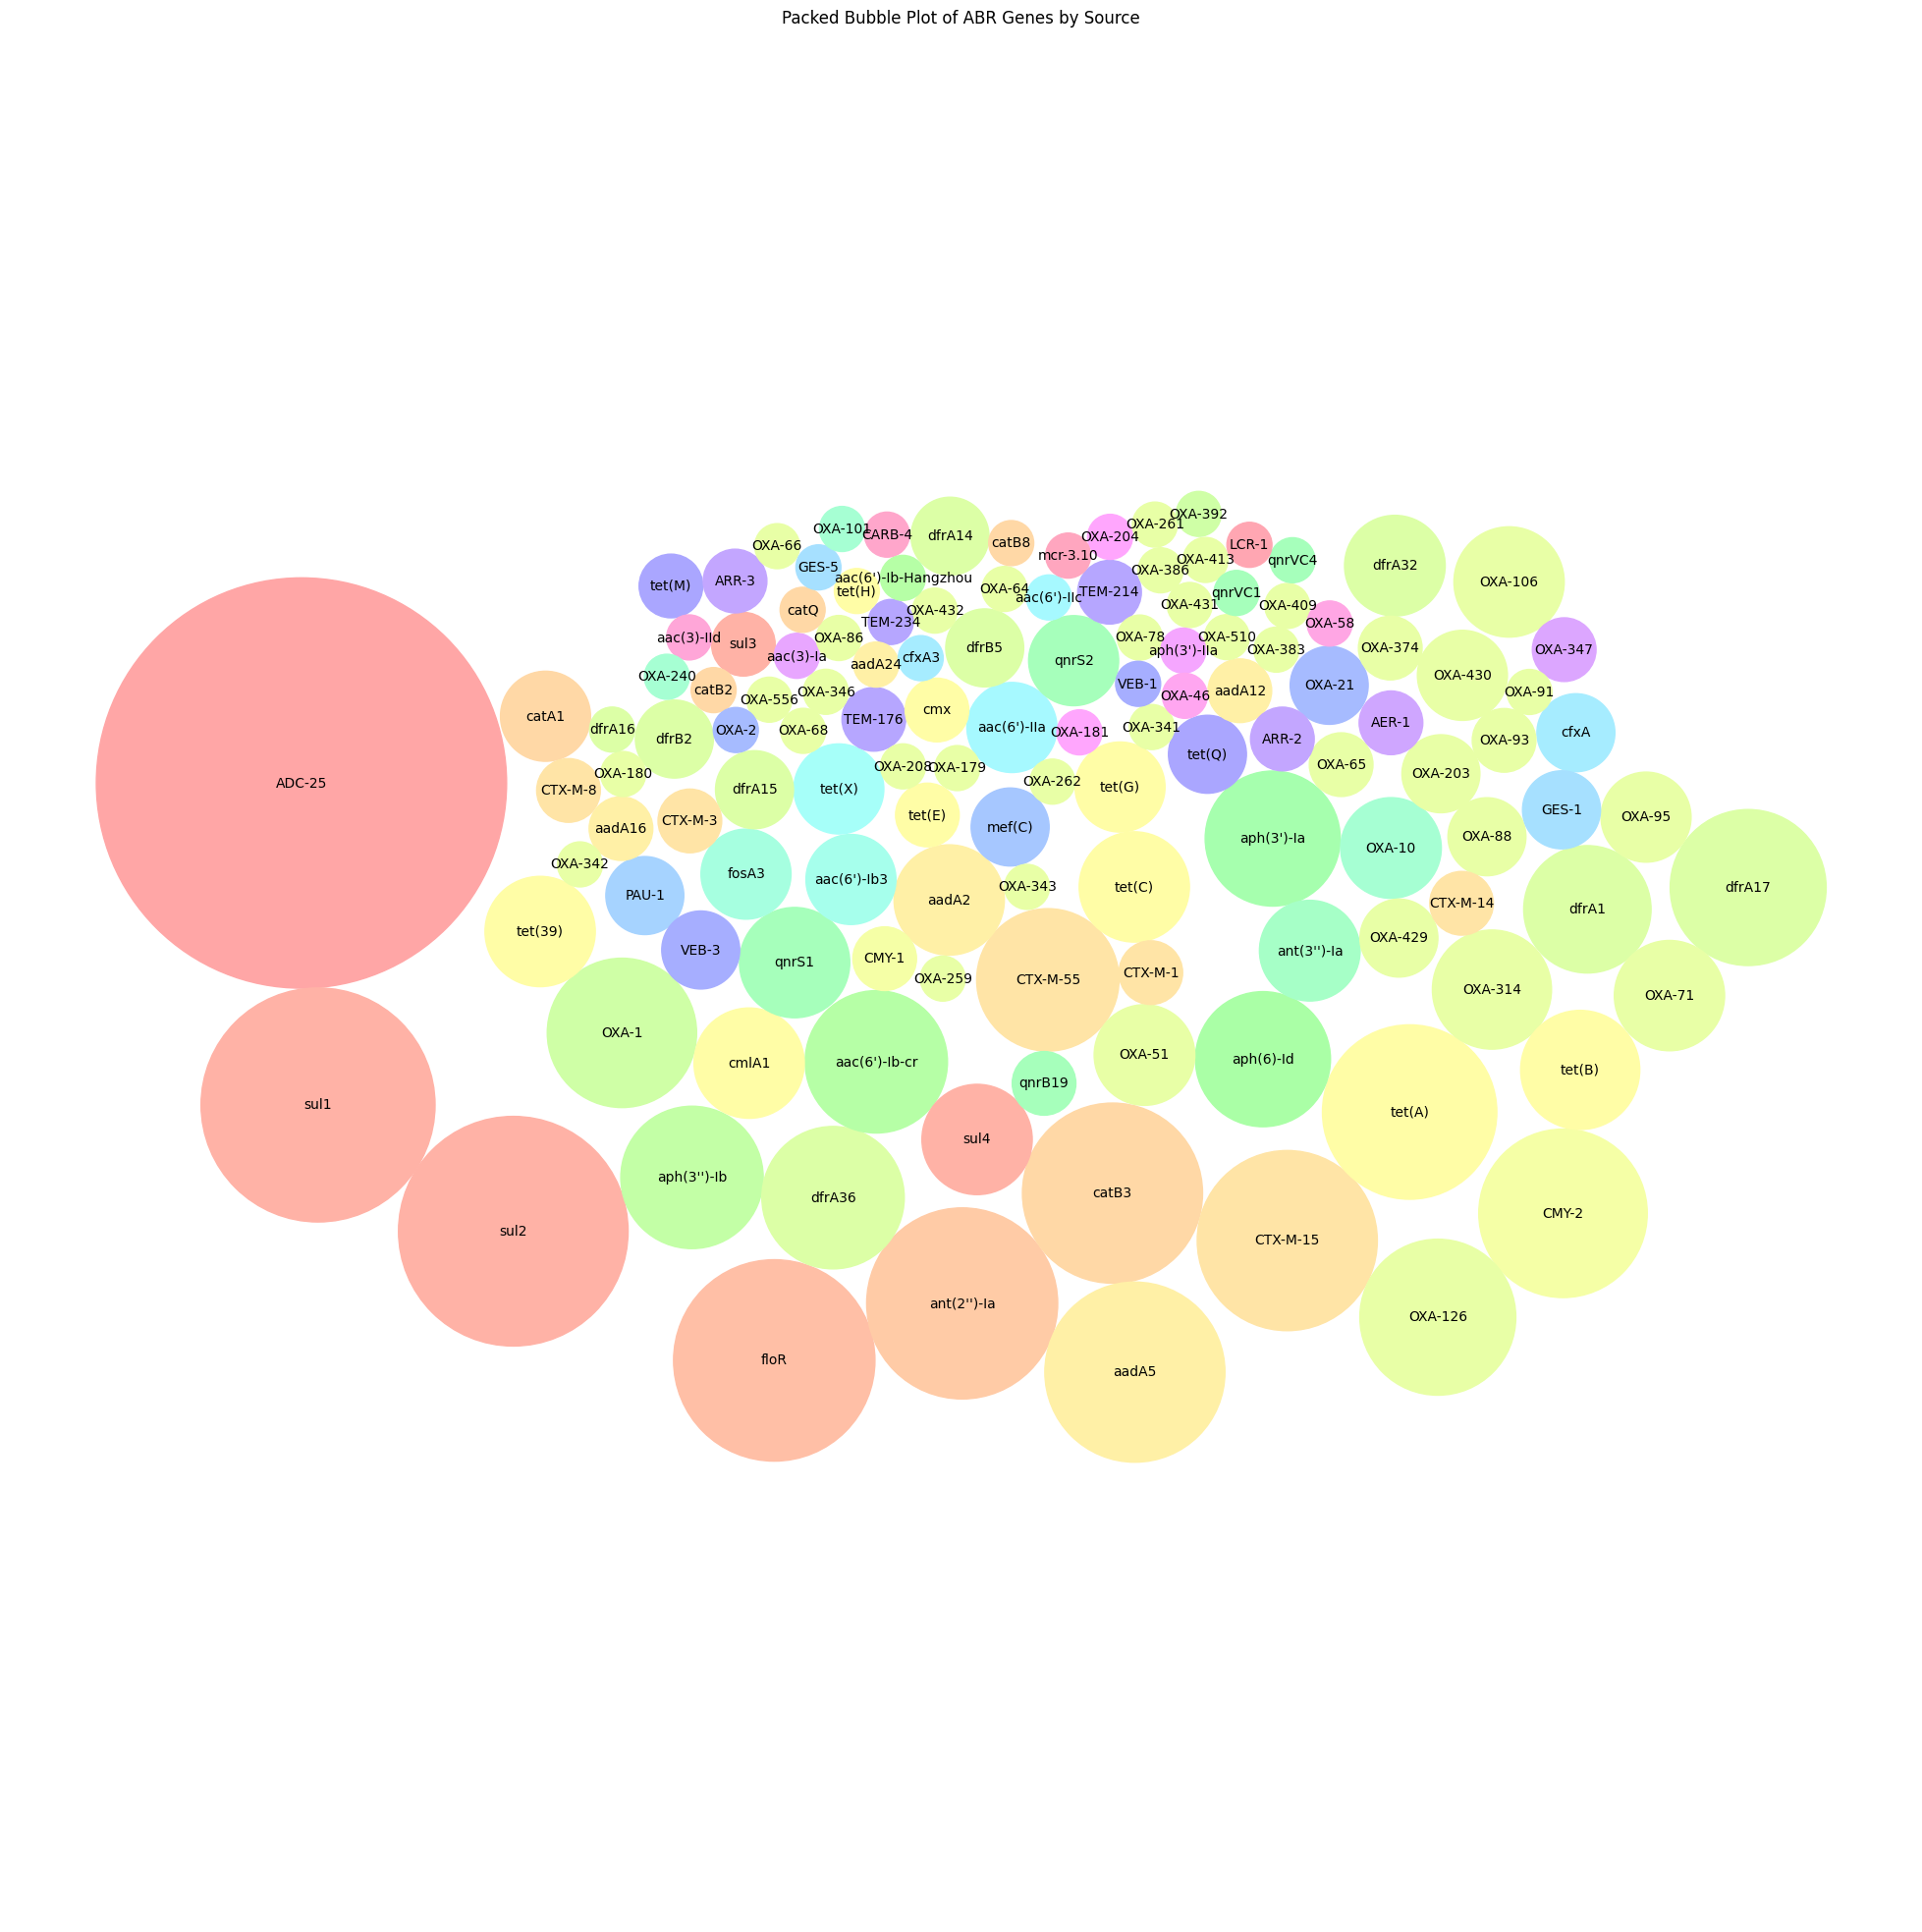

In [7]:
# use the BubbleChart class to create a packed bubble plot of ABR genes by source
area = df["count"]  # use sample_id as area for the bubbles
labels = df[["gene", "aro_parent_class"]]  # use ABR_gene as labels for the bubbles and get the parent classes to show the bubbles with a similar aro_parent_class with the same color 

# use pastel colors for the bubbles using a color map. Get one color for each aro_parent_class found
hues = np.linspace(0, 1, df['aro_parent_class'].nunique(), endpoint=False)

# pastel colors: low saturation + high value
colors = [mcolors.hsv_to_rgb((h, 0.35, 1.0)) for h in hues]

bubble_chart = BubbleChart(area, labels)
bubble_chart.collapse()
fig, ax = plt.subplots(figsize=(25, 25), subplot_kw=dict(aspect="equal"))
bubble_chart.plot(ax, labels, colors)
plt.title("Packed Bubble Plot of ABR Genes by Source")
plt.axis("equal")
plt.axis("off")
plt.show()

In [110]:
## Test having multiple centers of gravity

import numpy as np
import matplotlib.pyplot as plt


class BubbleChart:

    def __init__(
        self,
        area,
        parent_classes,
        bubble_spacing=5,
        cluster_radius=10,
        attraction_strength=0.05,
        repulsion_strength=5,
        cluster_repulsion_strength=50,
    ):

        area = np.asarray(area * 10)
        r = np.sqrt(area / np.pi)

        self.parent_classes = np.asarray(parent_classes)
        self.unique_classes = np.unique(self.parent_classes)

        self.bubble_spacing = bubble_spacing
        self.attraction_strength = attraction_strength
        self.repulsion_strength = repulsion_strength
        self.cluster_repulsion_strength = cluster_repulsion_strength

        # x, y, radius, area
        self.bubbles = np.zeros((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area

        angles = np.linspace(
            0,
            2 * np.pi,
            len(self.unique_classes),
            endpoint=False
        )

        self.cluster_centers = {
            cls: np.array([
                cluster_radius * np.cos(angle),
                cluster_radius * np.sin(angle)
            ])
            for cls, angle in zip(self.unique_classes, angles)
        }

        for i, cls in enumerate(self.parent_classes):

            center = self.cluster_centers[cls]

            self.bubbles[i, 0] = center[0] + np.random.normal(scale=10)
            self.bubbles[i, 1] = center[1] + np.random.normal(scale=10)


    def compute_cluster_coms(self):

        coms = {}

        for cls in self.unique_classes:

            idx = self.parent_classes == cls

            coms[cls] = np.average(
                self.bubbles[idx, :2],
                axis=0,
                weights=self.bubbles[idx, 3]
            )

        return coms

    
    def update_cluster_centers(self):

        coms = self.compute_cluster_coms()

        for cls1 in self.unique_classes:

            force = np.zeros(2)

            for cls2 in self.unique_classes:

                if cls1 == cls2:
                    continue

                vec = coms[cls1] - coms[cls2]

                dist = np.linalg.norm(vec)

                if dist < 1:
                    dist = 1

                force += (
                    vec / dist
                ) * self.cluster_repulsion_strength / dist**2

            self.cluster_centers[cls1] += force
            

    def overlap_force(self, i):

        pos_i = self.bubbles[i, :2]
        r_i = self.bubbles[i, 2]

        total_force = np.zeros(2)

        for j in range(len(self.bubbles)):

            if i == j:
                continue

            pos_j = self.bubbles[j, :2]
            r_j = self.bubbles[j, 2]

            vec = pos_i - pos_j
            dist = np.linalg.norm(vec)

            if dist < 1e-6:
                vec = np.random.randn(2)
                dist = np.linalg.norm(vec)

            min_dist = (
                r_i
                + r_j
                + self.bubble_spacing
            )

            overlap = min_dist - dist

            if overlap > 0:

                total_force += (
                    vec / dist
                ) * overlap * self.repulsion_strength

        return total_force
        

    def collapse(self, n_iterations=300):

        for _ in range(n_iterations):

            self.update_cluster_centers()

            for i in range(len(self.bubbles)):

                cls = self.parent_classes[i]

                pos = self.bubbles[i, :2]

                cluster_center = self.cluster_centers[cls]

                attraction = (
                    cluster_center - pos
                ) * self.attraction_strength

                repulsion = self.overlap_force(i)

                movement = attraction + repulsion

                self.bubbles[i, :2] += movement


    def plot(self, ax, labels, colors):
        """
        Parameters
        ----------
        ax : matplotlib.axes.Axes
        
        labels : pd.DataFrame
            Must contain:
                - gene
                - aro_parent_class
        
        colors : list
            One color per unique aro_parent_class.
        """

        unique_classes = np.unique(self.parent_classes)
    
        if len(colors) < len(unique_classes):
            raise ValueError(
                f"{len(unique_classes)} classes but only "
                f"{len(colors)} colors provided."
            )
    
        class_to_color = {
            cls: colors[i]
            for i, cls in enumerate(unique_classes)
        }
    
        for i in range(len(self.bubbles)):
    
            cls = self.parent_classes[i]
    
            circ = plt.Circle(
                self.bubbles[i, :2],
                self.bubbles[i, 2],
                color=class_to_color[cls],
                alpha=0.8,
            )
    
            ax.add_patch(circ)
    
            ax.text(
                self.bubbles[i, 0],
                self.bubbles[i, 1],
                labels["gene"].iloc[i],
                ha="center",
                va="center",
                fontsize=10,
            )

            legend_handles = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=cls
                )
                for cls, color in class_to_color.items()
            ]
            
            ax.legend(
                handles=legend_handles,
                title="ARO Parent Class",
                title_fontsize=16,
                loc="upper center", #loc="upper left",
                bbox_to_anchor=(0, -0.01, 1, 0), #bbox_to_anchor=(1.02, 1),
                mode="expand",
                borderaxespad=0,
                fontsize=12
            )

        ax.set_aspect("equal")
        ax.autoscale_view()

In [111]:
## Filtration of the Antibiotic resistance classes for visualization
## We opted to reduce the number of resistance genes we show in the representation to make it more readable. 

## Filtration of antibiotic genes that have a parent antibiotic aro term that is unique in the query result and with a number of occurences 
## below 50

parent_counts = df["aro_parent_class_label"].value_counts()

df_filtered = df[
    ~(
        df["aro_parent_class_label"].map(parent_counts).eq(1)
        & df["count"].lt(50)
    )
]


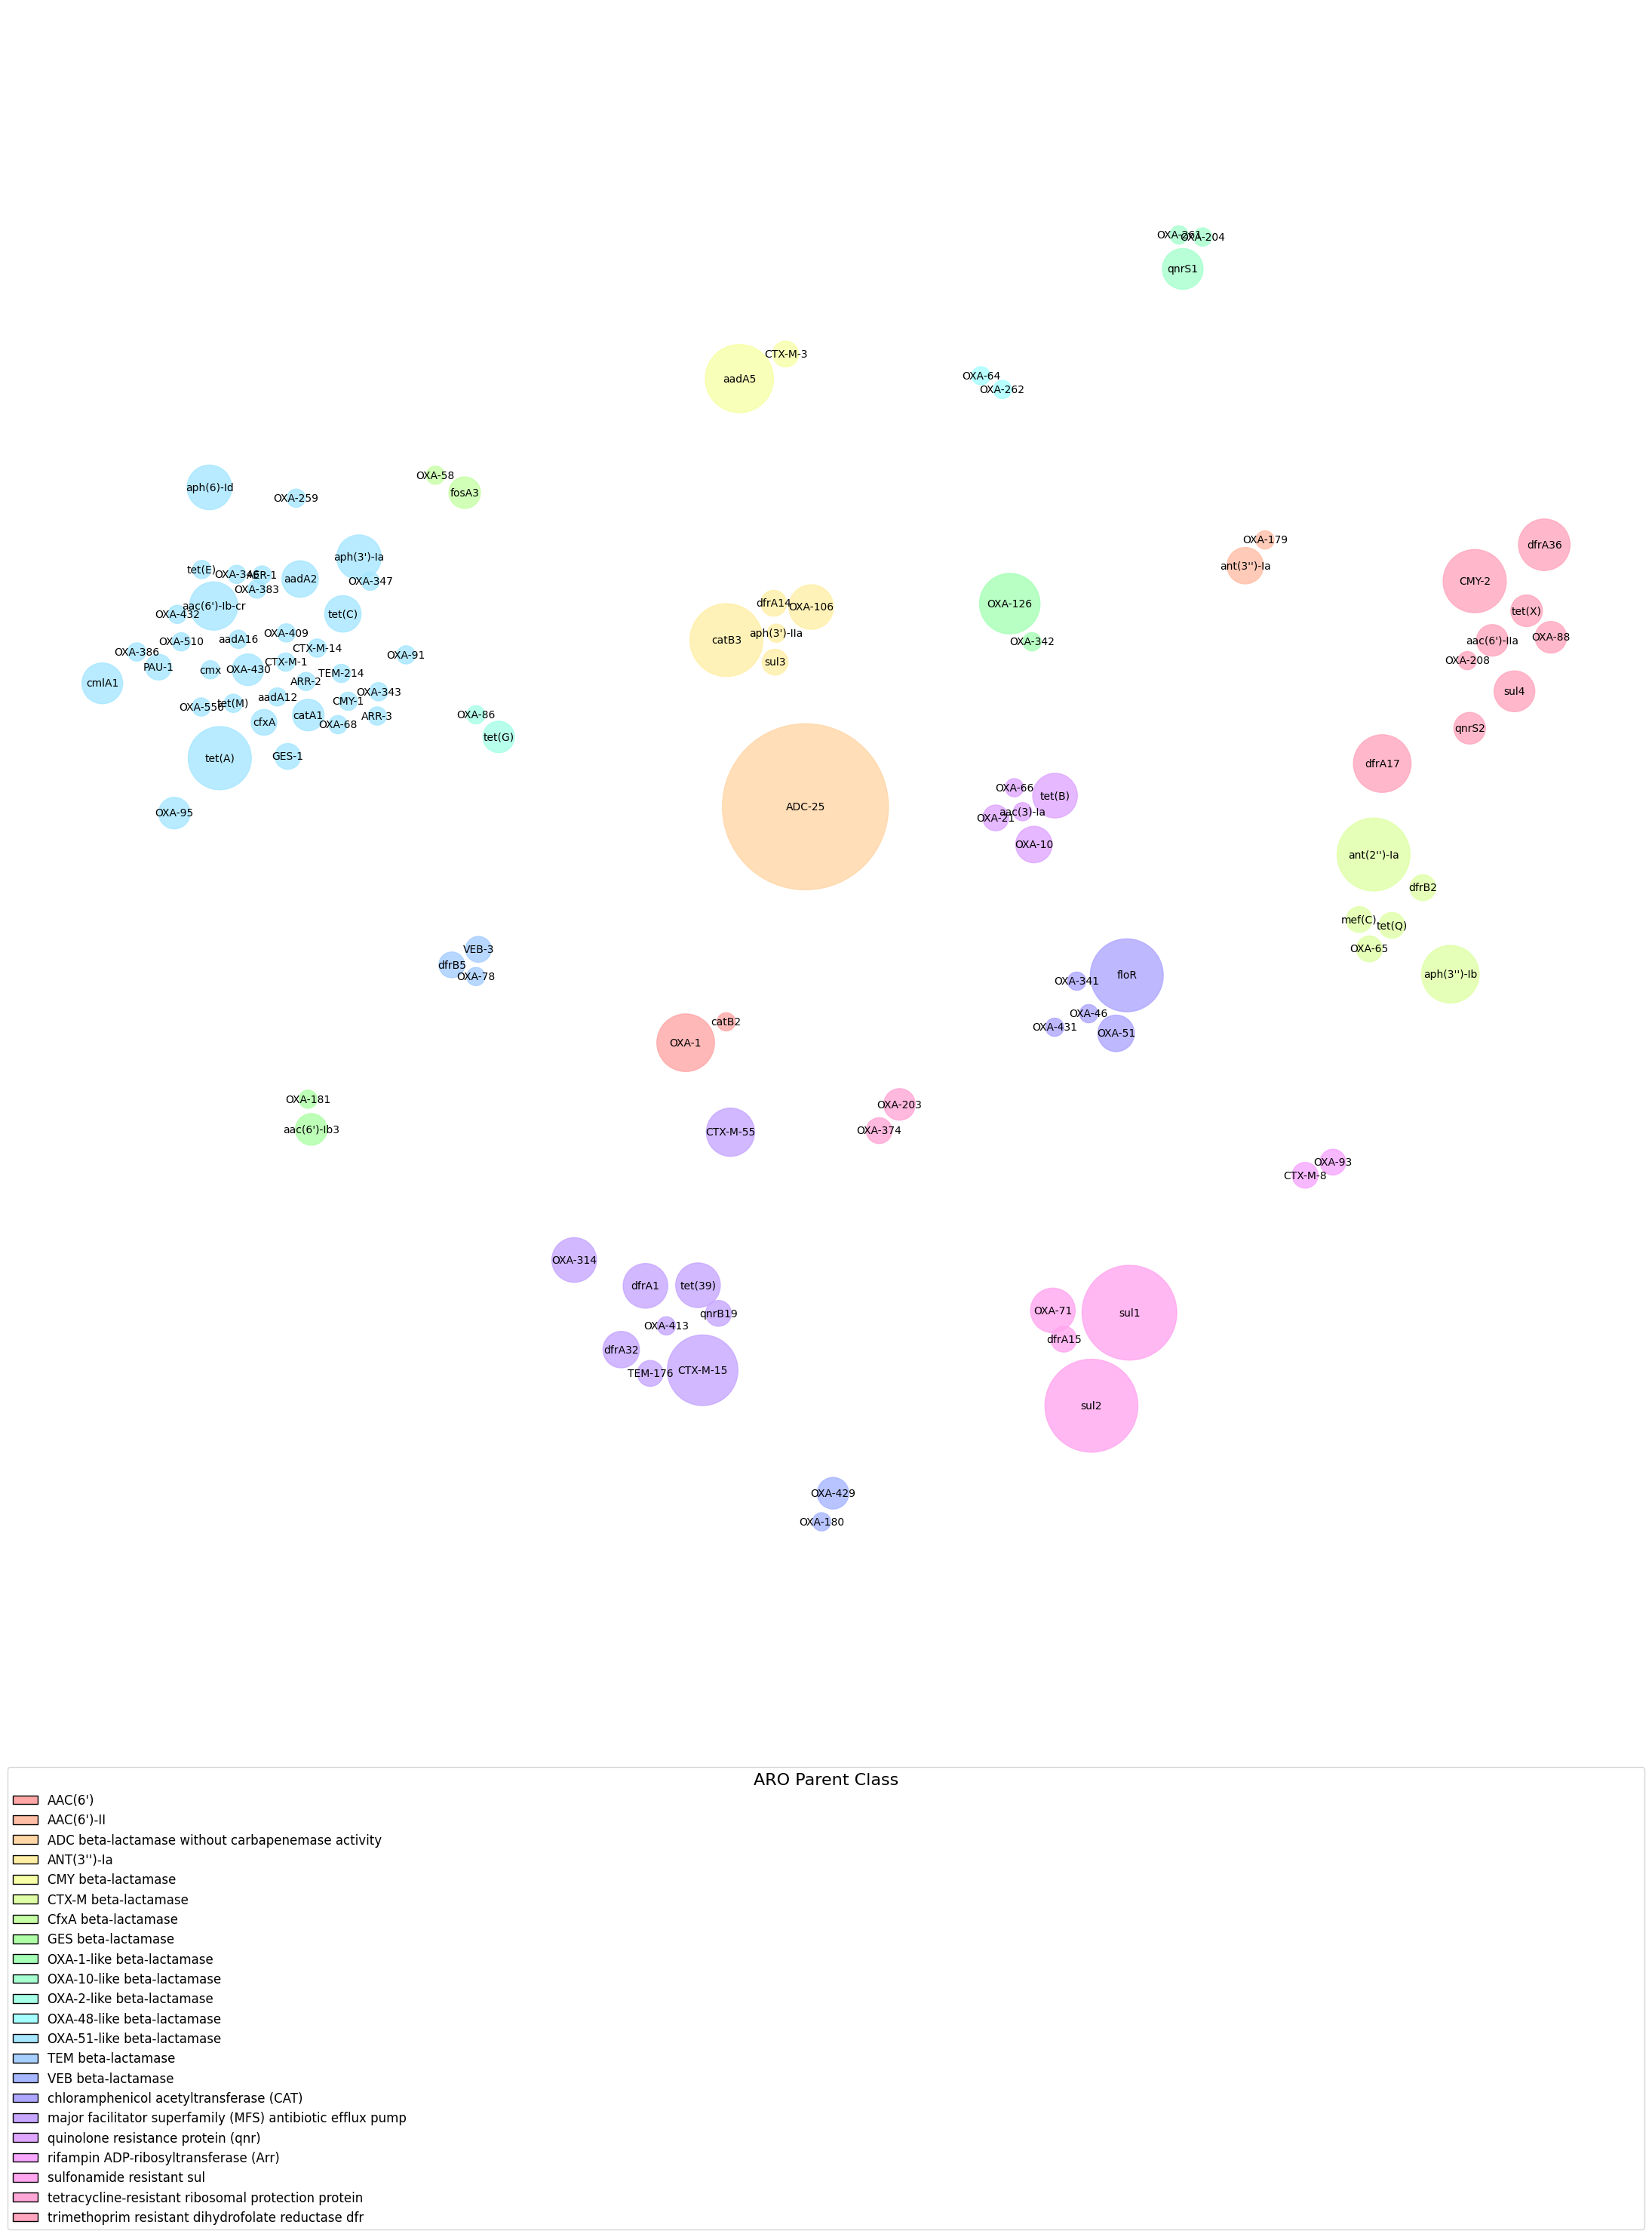

In [113]:
bubble_chart = BubbleChart(
    area=df_filtered["count"],
    parent_classes=df_filtered["aro_parent_class_label"],
    bubble_spacing=1,
)

# use pastel colors for the bubbles using a color map. Get one color for each aro_parent_class found
hues = np.linspace(0, 1, df_filtered['aro_parent_class_label'].nunique(), endpoint=False)

# pastel colors: low saturation + high value
colors = [mcolors.hsv_to_rgb((h, 0.35, 1.0)) for h in hues]

bubble_chart.collapse(500)

## Create the plot

fig, ax = plt.subplots(figsize=(28, 30))

bubble_chart.plot(
    ax=ax,
    labels=df,
    colors=colors
)
#plt.subplots_adjust(right=0.80)
# plt.title("Packed Bubble Plot of ABR Genes by Source", fontsize=26) ## Not included in the Figure submitted in the article
plt.axis("equal")
plt.axis("off")
plt.savefig("figure-2.pdf", dpi=450, bbox_inches="tight")
plt.show()